# NAVYA — Final Model Evaluation

This notebook refits the tuned winner on the 900 training-plus-validation women, then evaluates once on the 100 held-out test women. It also tests whether lifestyle/history signals improve on the previous-three-cycle mean baseline.

## 1. Load selection, recreate the locked split, and rebuild the estimator

The test partition is reconstructed deterministically and remains absent from training and tuning. The factory reproduces the selected tuned pipeline from its recorded parameters.

In [1]:
from pathlib import Path
import json, joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
)
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

ROOT = Path.cwd().resolve()
ROOT = ROOT if (ROOT / "data").exists() else ROOT.parent
FEATURES = [
    "age_years",
    "menarche_age",
    "height_cm",
    "weight_kg",
    "bmi",
    "sleep_hours",
    "stress_level",
    "exercise_frequency",
    "uses_medication_or_contraceptive",
    "prev_cycle_1",
    "prev_cycle_2",
    "prev_cycle_3",
    "avg_previous_cycle_length",
    "std_previous_cycle_length",
    "prev_period_1",
    "prev_period_2",
    "prev_period_3",
    "avg_previous_period_length",
]
df = pd.read_csv(ROOT / "processed_data" / "model_ready_dataset.csv")
women = np.random.RandomState(42).permutation(np.sort(df.woman_id.unique()))
train = df[df.woman_id.isin(women[:800])].copy()
validation = df[df.woman_id.isin(women[800:900])].copy()
test = df[df.woman_id.isin(women[900:])].copy()
assert not (set(train.woman_id) & set(validation.woman_id))
assert not (set(train.woman_id) & set(test.woman_id))
assert not (set(validation.woman_id) & set(test.woman_id))
print(f"Rows — train: {len(train):,}; validation: {len(validation):,}; test: {len(test):,}")
print("Woman overlap checks — train∩validation: 0; train∩test: 0; validation∩test: 0")
with open(ROOT / "results" / "tuning" / "best_tuned_model.json") as f:
    selected = json.load(f)


def make_model(name, params):
    klass = {
        "GradientBoostingRegressor": GradientBoostingRegressor,
        "RandomForestRegressor": RandomForestRegressor,
        "XGBRegressor": XGBRegressor,
        "SVR": SVR,
    }[name]
    defaults = {"random_state": 42}
    if name == "RandomForestRegressor":
        defaults["n_jobs"] = -1
    if name == "XGBRegressor":
        defaults.update({"objective": "reg:squarederror", "n_jobs": -1})
    defaults.update({k.replace("model__", ""): v for k, v in params.items()})
    estimator = klass(**defaults)
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if name == "SVR":
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", estimator))
    return Pipeline(steps)


# Configuration and uncertainty threshold are fixed before the test set is accessed.
with open(ROOT / "results" / "metrics" / "uncertainty_calibration.json") as f: uncertainty = json.load(f)
assert uncertainty["selected_model"] == selected["model"] == "XGBRegressor", (
    "Selected-model metadata is stale. Re-run Notebooks 05, 08, then 09 in order."
)
coverage = uncertainty["coverage"]; q_hat = uncertainty["q_hat_days"]
supported_cycle_lower_bound = uncertainty["supported_cycle_lower_bound"]
supported_cycle_upper_bound = uncertainty["supported_cycle_upper_bound"]
X_test, y_test = test[FEATURES], test.next_cycle_length_days
final_pipeline = joblib.load(ROOT / "models" / "calibrated_cycle_length_model.joblib")
assert final_pipeline.named_steps["model"].__class__.__name__ == selected["model"], (
    "Calibrated model artifact is stale. Re-run Notebook 08 before this final evaluation."
)
pred = final_pipeline.predict(X_test)
print(f"Locked model: {selected['model']}; grouped CV MAE: {selected['best_cv_mae']:.4f}; conformal q_hat: {q_hat:.3f} days")

Rows — train: 16,000; validation: 2,000; test: 2,000
Woman overlap checks — train∩validation: 0; train∩test: 0; validation∩test: 0
Locked model: XGBRegressor; grouped CV MAE: 1.2332; conformal q_hat: 2.173 days


## 2. Locked final evaluation, baseline, and uncertainty

The final model configuration was fixed before accessing the test-set results. MAE expresses prediction error directly in days, while the previous-three-cycle mean baseline tests whether machine learning adds practical value. The conformal interval is calibrated only on validation women, then checked once on the final test women.

In [2]:
def metrics(y,p): return {'MAE':mean_absolute_error(y,p),'MSE':mean_squared_error(y,p),'RMSE':mean_squared_error(y,p)**.5,'R2':r2_score(y,p),'within_1_day_pct':float((np.abs(np.asarray(y)-np.asarray(p)) <= 1).mean()*100),'within_2_days_pct':float((np.abs(np.asarray(y)-np.asarray(p)) <= 2).mean()*100)}
baseline=test[['prev_cycle_1','prev_cycle_2','prev_cycle_3']].mean(axis=1).to_numpy()
final_metrics=metrics(y_test,pred); baseline_metrics=metrics(y_test,baseline)
comparison=pd.DataFrame([{'model':'Final ML model',**final_metrics},{'model':'Previous-3 mean baseline',**baseline_metrics}])
display(comparison.round(4))
improvements={'mae_improvement':baseline_metrics['MAE']-final_metrics['MAE'],'mae_improvement_pct':(baseline_metrics['MAE']-final_metrics['MAE'])/baseline_metrics['MAE']*100,'rmse_improvement':baseline_metrics['RMSE']-final_metrics['RMSE'],'r2_difference':final_metrics['R2']-baseline_metrics['R2']}
test_interval_lower = pred - q_hat; test_interval_upper = pred + q_hat
uncertainty_metrics = {'method':'split_conformal','nominal_coverage':coverage,'q_hat_days':q_hat,'observed_test_coverage':float(((y_test.to_numpy() >= test_interval_lower) & (y_test.to_numpy() <= test_interval_upper)).mean()),'average_interval_width_days':float(np.mean(test_interval_upper-test_interval_lower)),'supported_cycle_lower_bound':supported_cycle_lower_bound,'supported_cycle_upper_bound':supported_cycle_upper_bound}
display(pd.DataFrame([uncertainty_metrics]).round(4))
display(pd.DataFrame([improvements]).round(4))
metrics_dir=ROOT/'results'/'metrics'; metrics_dir.mkdir(parents=True,exist_ok=True)
with open(metrics_dir/'final_evaluation.json','w') as f: json.dump({'selected_model':selected,'final_test_metrics':final_metrics,'baseline_test_metrics':baseline_metrics,'improvements':improvements,'uncertainty':uncertainty_metrics},f,indent=2)
comparison.to_csv(metrics_dir/'final_test_comparison.csv',index=False)

,model,MAE,MSE,RMSE,R2,within_1_day_pct,within_2_days_pct
0,Final ML model,1.1872,2.8511,1.6885,0.7929,56.5,84.65
1,Previous-3 mean baseline,1.2232,3.1412,1.7723,0.7718,62.5,85.70


,method,nominal_coverage,q_hat_days,observed_test_coverage,average_interval_width_days,supported_cycle_lower_bound,supported_cycle_upper_bound
0,split_conformal,0.9,2.173,0.8685,4.346,17.0,39.0


,mae_improvement,mae_improvement_pct,rmse_improvement,r2_difference
0,0.036,2.9398,0.0838,0.0211


## 3. Prediction diagnostics

Scatter, residual distribution, residual-versus-predicted, and true-cycle bins reveal calibration and where the model makes larger errors.

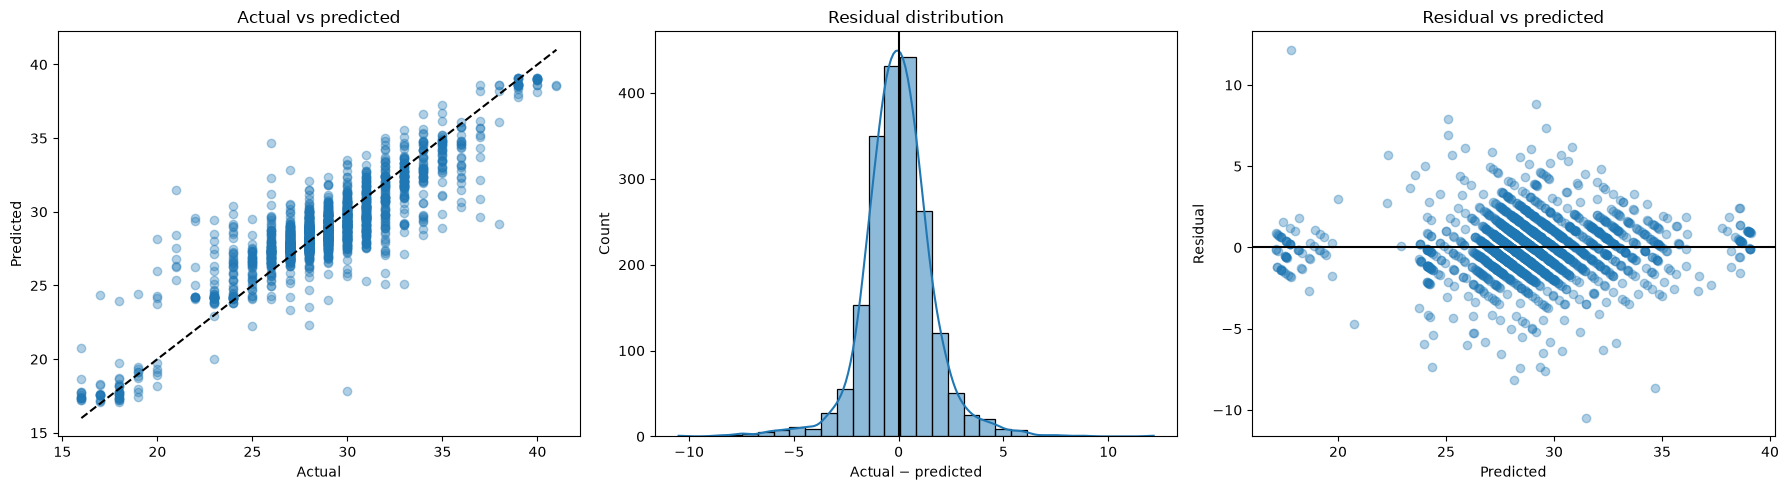

,n,mae
range,,
"(13.999, 22.0]",87,2.067753
"(22.0, 26.0]",246,1.664928
"(26.0, 30.0]",1155,0.880185
"(30.0, 34.0]",393,1.472788
"(34.0, 60.0]",119,1.592694


count    2000.000000
mean       -0.021861
std         1.688798
min       -10.500389
25%        -0.885445
50%        -0.048527
75%         0.835712
max        12.168756
dtype: float64


In [3]:
resid = y_test.to_numpy() - pred
plots = ROOT / "results" / "plots"
plots.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].scatter(y_test, pred, alpha=0.35)
lo, hi = min(y_test.min(), pred.min()), max(y_test.max(), pred.max())
ax[0].plot([lo, hi], [lo, hi], "k--")
ax[0].set(xlabel="Actual", ylabel="Predicted", title="Actual vs predicted")
sns.histplot(resid, bins=30, kde=True, ax=ax[1])
ax[1].axvline(0, color="k")
ax[1].set(title="Residual distribution", xlabel="Actual − predicted")
ax[2].scatter(pred, resid, alpha=0.35)
ax[2].axhline(0, color="k")
ax[2].set(xlabel="Predicted", ylabel="Residual", title="Residual vs predicted")
plt.tight_layout()
plt.savefig(plots / "final_diagnostics.png", dpi=160, bbox_inches="tight")
plt.show()
bins = pd.cut(y_test, [14, 22, 26, 30, 34, 60], include_lowest=True)
error_by_range = (
    pd.DataFrame({"range": bins.astype(str), "absolute_error": np.abs(resid)})
    .groupby("range", observed=False)
    .agg(n=("absolute_error", "size"), mae=("absolute_error", "mean"))
)
display(error_by_range)
print(pd.Series(resid).describe())

## 4. Permutation importance

Permutation importance measures the increase in held-out MAE when one feature is shuffled. It supports a cautious conclusion about whether lifestyle variables add information beyond previous-cycle history.

,feature,mae_increase_when_permuted,std
12,avg_previous_cycle_length,1.009830,0.018987
9,prev_cycle_1,0.833078,0.017125
11,prev_cycle_3,0.065013,0.003999
10,prev_cycle_2,0.011912,0.002862
13,std_previous_cycle_length,0.008187,0.002579
6,stress_level,0.004409,0.001648
5,sleep_hours,0.004000,0.000991
17,avg_previous_period_length,0.000276,0.000213
14,prev_period_1,0.000214,0.000288
2,height_cm,0.000139,0.000139


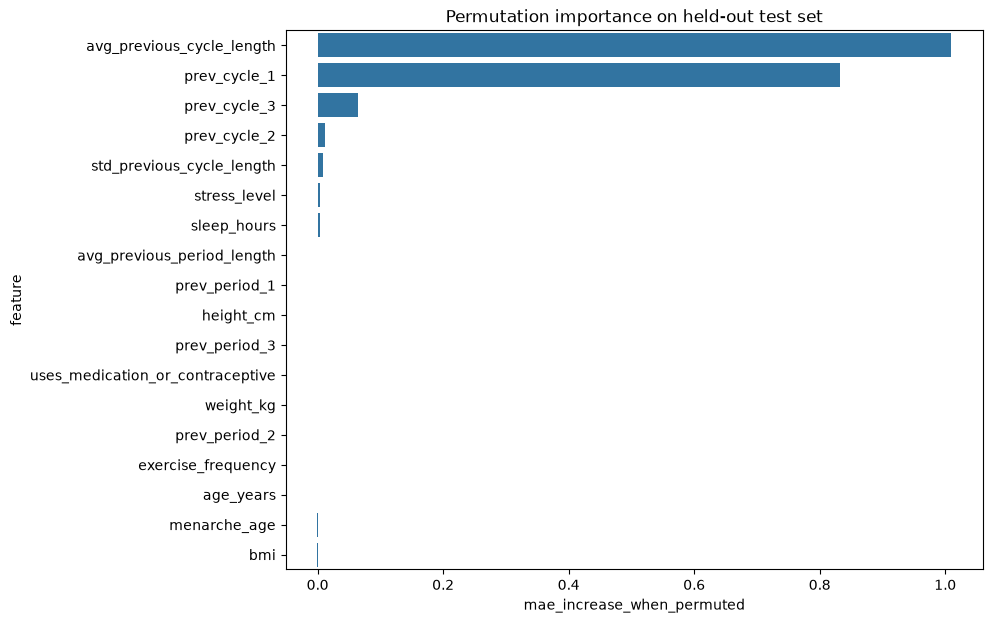

Interpretation: only features with clearly positive held-out MAE increase provide evidence of useful predictive contribution. Do not claim lifestyle importance if their values are near zero or unstable.


In [4]:
perm = permutation_importance(
    final_pipeline,
    X_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)
importance = pd.DataFrame(
    {
        "feature": FEATURES,
        "mae_increase_when_permuted": perm.importances_mean,
        "std": perm.importances_std,
    }
).sort_values("mae_increase_when_permuted", ascending=False)
display(importance)
importance.to_csv(metrics_dir / "permutation_importance.csv", index=False)
plt.figure(figsize=(9, 7))
sns.barplot(data=importance, y="feature", x="mae_increase_when_permuted")
plt.title("Permutation importance on held-out test set")
plt.show()
print(
    "Interpretation: only features with clearly positive held-out MAE increase provide evidence of useful predictive contribution. Do not claim lifestyle importance if their values are near zero or unstable."
)

## Observation

Use the held-out comparison and permutation table, rather than intuition, to decide whether this model genuinely improves on the previous-three-cycle average and whether lifestyle variables contribute meaningful incremental signal.